# Supervised Learning

## Classification

### Preparation

Untuk persiapan, kita akan memanggil seluruh library yang akan kita pakai pada project kali ini

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
%matplotlib inline

In [3]:
train = pd.read_csv('Iris.csv')
train.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


### Exploratory Data Analysis

In [4]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB


In [5]:
d = train.describe()
d

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


<Axes: xlabel='Species', ylabel='count'>

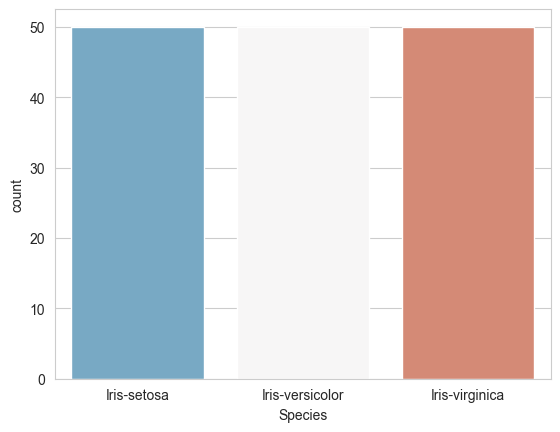

In [6]:
# Cek relative size dari survived dan not survived
sns.set_style('whitegrid')
sns.countplot(x='Species', data=train, hue='Species', palette='RdBu_r', legend=False)

<Axes: xlabel='Species', ylabel='PetalLengthCm'>

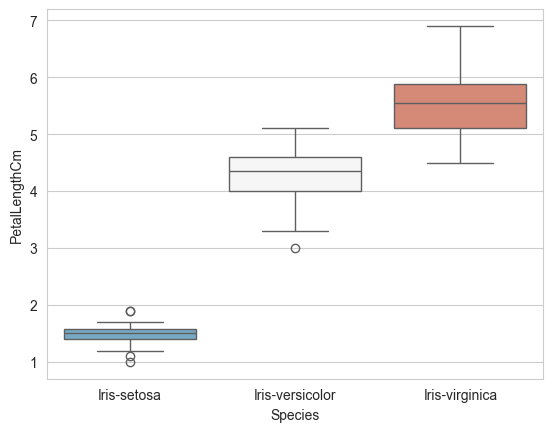

In [7]:
# Survivablity vs sex
sns.set_style('whitegrid')
sns.boxplot(x='Species', y='PetalLengthCm', data=train, palette='RdBu_r', hue='Species', legend=False)

<Axes: xlabel='Species', ylabel='SepalWidthCm'>

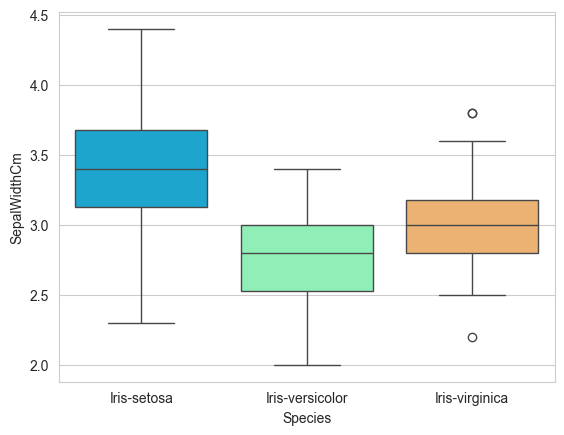

In [8]:
# Survivablity vs passenger class
sns.set_style('whitegrid')
sns.boxplot(x='Species', y='SepalWidthCm', data=train, palette='rainbow', hue='Species', legend=False)

                 PetalLengthCm
Species                       
Iris-setosa              1.464
Iris-versicolor          4.260
Iris-virginica           5.552


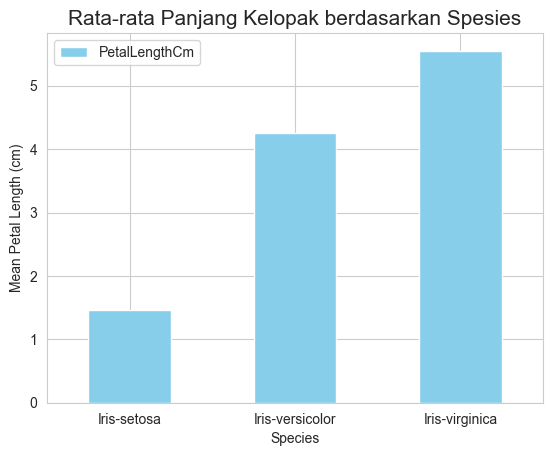

In [9]:
# Menghitung rata-rata PetalLengthCm per Spesies
f_species_petal = train.groupby('Species')['PetalLengthCm'].mean()
f_species_petal = pd.DataFrame(f_species_petal)

# Menampilkan tabel hasil grouping
print(f_species_petal)

# Membuat Bar Chart
f_species_petal.plot.bar(y='PetalLengthCm', color='skyblue')
plt.title("Rata-rata Panjang Kelopak berdasarkan Spesies", fontsize=15)
plt.ylabel("Mean Petal Length (cm)")
plt.xticks(rotation=0)
plt.show()

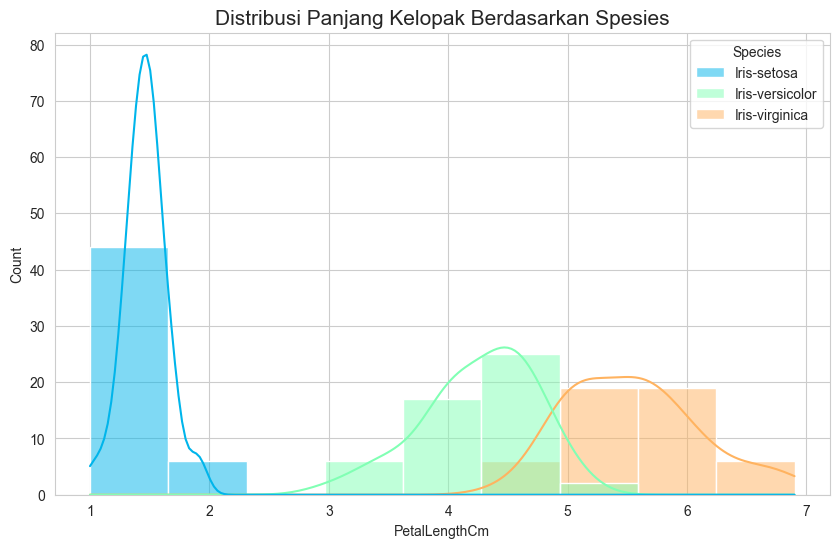

In [10]:
sns.set_style('whitegrid')
plt.figure(figsize=(10,6))
sns.histplot(data=train, x='PetalLengthCm', hue='Species', kde=True, palette='rainbow')
plt.title("Distribusi Panjang Kelopak Berdasarkan Spesies", fontsize=15)
plt.show()

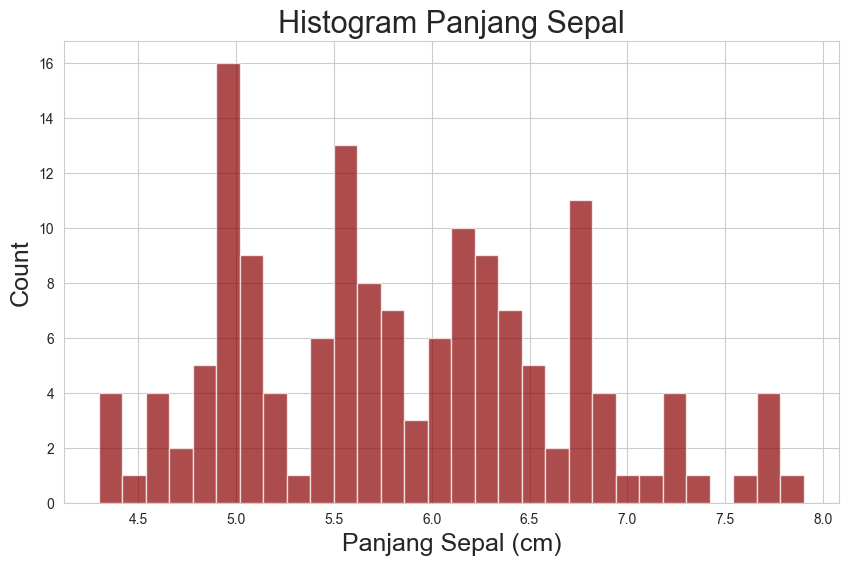

In [11]:
# Cek distribusi dari Sepal Length
plt.figure(figsize=(10,6))
plt.xlabel("Panjang Sepal (cm)", fontsize=18)
plt.ylabel("Count", fontsize=18)
plt.title("Histogram Panjang Sepal", fontsize=22)

# Menggunakan fitur SepalLengthCm sebagai pengganti 'Age'
train['SepalLengthCm'].hist(bins=30, color='darkred', alpha=0.7)
plt.show()

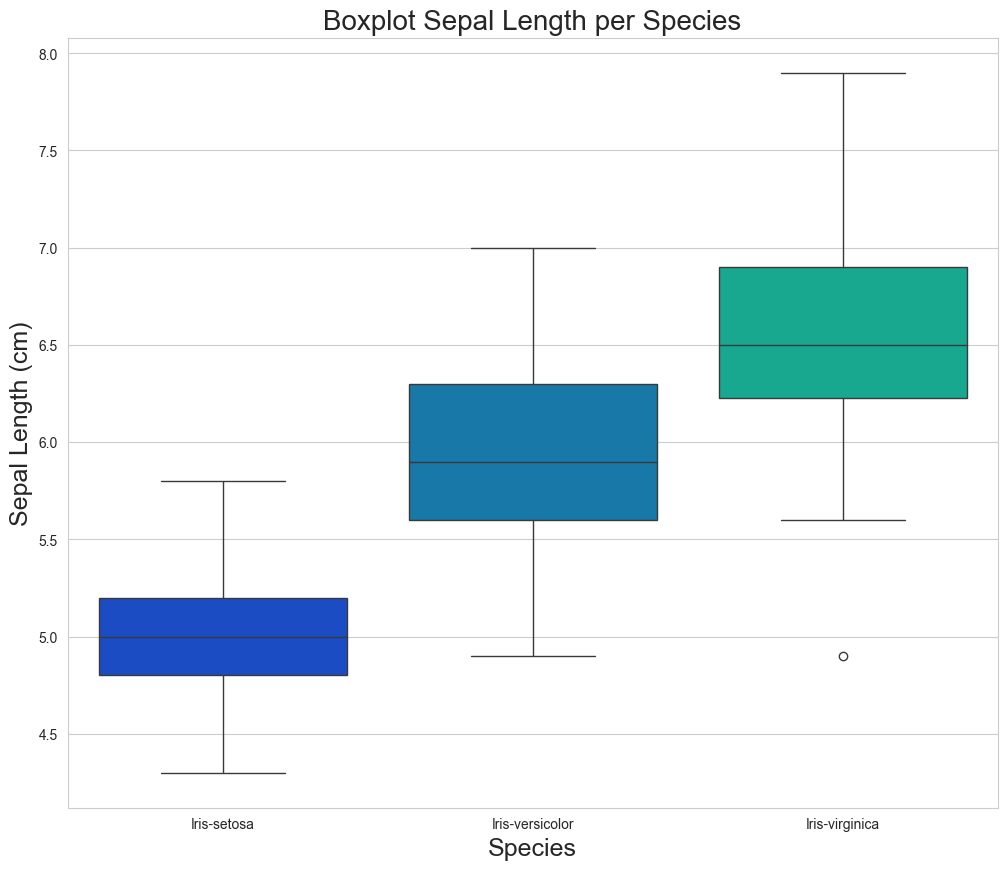

In [12]:
# Distribusi panjang sepal di setiap spesies
plt.figure(figsize=(12, 10))
plt.xlabel("Species", fontsize=18)
plt.ylabel("Sepal Length (cm)", fontsize=18)
plt.title("Boxplot Sepal Length per Species", fontsize=20)

# Menggunakan 'Species' sebagai pengganti 'Pclass' 
# dan 'SepalLengthCm' sebagai pengganti 'Age'
sns.boxplot(x='Species', y='SepalLengthCm', data=train, palette='winter', hue='Species', legend=False)
plt.show()

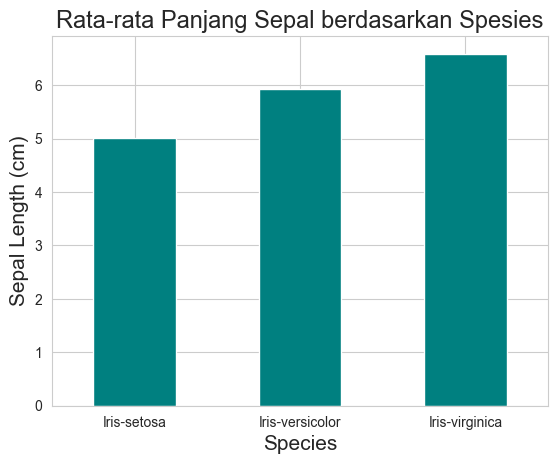

In [13]:
# Menghitung rata-rata SepalLengthCm per Spesies
f_species_sepal = train.groupby('Species')['SepalLengthCm'].mean()
f_species_sepal = pd.DataFrame(f_species_sepal)

# Membuat Bar Chart
f_species_sepal.plot.bar(y='SepalLengthCm', color='teal', legend=False)

# Mengatur label dan judul
plt.title("Rata-rata Panjang Sepal berdasarkan Spesies", fontsize=17)
plt.ylabel("Sepal Length (cm)", fontsize=15)
plt.xlabel("Species", fontsize=15)
plt.xticks(rotation=0) # Agar tulisan spesies tidak miring
plt.show()

### Fitur Engineering

In [14]:
a = list(f_species_sepal['SepalLengthCm'])

def impute_sepal_length(cols):
    SepalLength = cols['SepalLengthCm']
    Species = cols['Species']
    
    if pd.isnull(SepalLength):
        if Species == 'Iris-setosa':
            return a[0]
        elif Species == 'Iris-versicolor':
            return a[1]
        else:
            return a[2]
    else:
        return SepalLength

In [15]:
train['SepalLengthCm'] = train[['SepalLengthCm', 'Species']].apply(impute_sepal_length, axis=1)

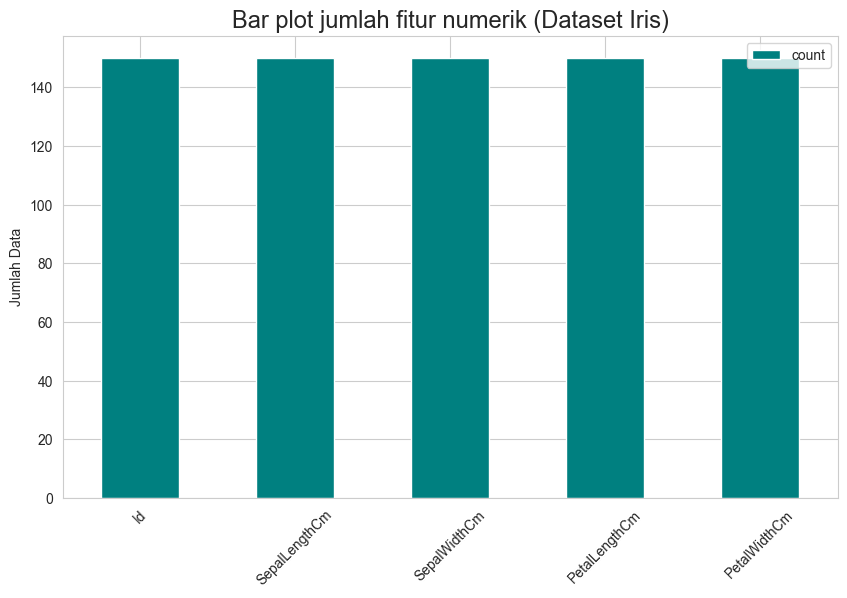

In [16]:
# 1. Ambil statistik deskriptif dari data Iris
d = train.describe()

# 2. Transpose tabelnya (baris jadi kolom, kolom jadi baris)
dT = d.T

# 3. Buat bar plot khusus untuk baris 'count'
dT.plot.bar(y='count', color='teal', figsize=(10,6))

# 4. Beri judul dan tampilkan
plt.title("Bar plot jumlah fitur numerik (Dataset Iris)", fontsize=17)
plt.ylabel("Jumlah Data")
plt.xticks(rotation=45) # Supaya nama fitur Iris tidak tabrakan
plt.show()

In [17]:
# drop cabin karena memiliki banyak null value (>50%)
train.drop('Id', axis=1, inplace=True)
train.dropna(inplace=True)
train.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [18]:
train.drop(['Id'], axis=1, inplace=True, errors='ignore')

# Tampilkan data
train.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [19]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
train['Species'] = le.fit_transform(train['Species'])
train.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


### Training

In [21]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(train.drop('Species', axis=1), 
                                                    train['Species'], 
                                                    test_size=0.30, 
                                                    random_state=42)

In [22]:
print(f"Jumlah data latihan (X_train): {len(X_train)}")
print(f"Jumlah data pengujian (X_test): {len(X_test)}")

Jumlah data latihan (X_train): 105
Jumlah data pengujian (X_test): 45


# **KNN**

In [23]:
from sklearn.neighbors import KNeighborsClassifier
clf1 = KNeighborsClassifier()
clf1.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [24]:
y_pred = clf1.predict(X_test)

### Evaluation

In [25]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy = accuracy_score(y_test, y_pred) #akurasi model
print(f'Akurasi Model KNN: {accuracy:.2f}')

print("Confusion Matrix:") #confusion matrix nya
print(confusion_matrix(y_test, y_pred))

print("Classification Report:") #laporan klasifikasi
print(classification_report(y_test, y_pred))

Akurasi Model KNN: 1.00
Confusion Matrix:
[[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



### jika kita mau mengubah parameter apa saja yang akan kita gunakan maka bisa dilakukan seperti ini

In [26]:
clf2 = KNeighborsClassifier(n_neighbors=5, weights='distance', metric='euclidean')
clf2.fit(X_train, y_train)

y_pred1 = clf2.predict(X_test)

In [27]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy = accuracy_score(y_test, y_pred1) #akurasi model
print(f'Akurasi Model KNN: {accuracy:.2f}')

print("Confusion Matrix:") #confusion matrix nya
print(confusion_matrix(y_test, y_pred1))

print("Classification Report:") #laporan klasifikasi
print(classification_report(y_test, y_pred1))

Akurasi Model KNN: 1.00
Confusion Matrix:
[[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



### jika ingin mencoba semua parameter

In [28]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import pandas as pd

# 1. Definisikan metrik-metrik scoring yang ingin digunakan
scoring = {
    'accuracy': make_scorer(accuracy_score),
    'precision': make_scorer(precision_score, average='macro'),
    'recall': make_scorer(recall_score, average='macro'),
    'f1': make_scorer(f1_score, average='macro')
}

# 2. Parameter grid
param_grid = {
    'n_neighbors': [3, 5, 7],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

# 3. Buat model KNN
knn = KNeighborsClassifier()

# 4. GridSearch dengan semua metrik, pilih 'f1' sebagai metrik utama (refit)
grid_search = GridSearchCV(knn, param_grid, cv=5, scoring=scoring, refit='f1', verbose=1, n_jobs=-1)
grid_search.fit(X_train, y_train)

# 5. Hasil Cross-Validation (Training)
cv_results = pd.DataFrame(grid_search.cv_results_)
cv_metrics = cv_results[['params', 'mean_test_accuracy', 'mean_test_precision', 'mean_test_recall', 'mean_test_f1']]
print("\n=== Hasil Evaluasi Training (Cross-Validation) ===")
print(cv_metrics.sort_values(by='mean_test_f1', ascending=False))

Fitting 5 folds for each of 12 candidates, totalling 60 fits

=== Hasil Evaluasi Training (Cross-Validation) ===
                                               params  mean_test_accuracy  \
5   {'metric': 'euclidean', 'n_neighbors': 7, 'wei...            0.952381   
4   {'metric': 'euclidean', 'n_neighbors': 7, 'wei...            0.952381   
1   {'metric': 'euclidean', 'n_neighbors': 3, 'wei...            0.942857   
2   {'metric': 'euclidean', 'n_neighbors': 5, 'wei...            0.942857   
8   {'metric': 'manhattan', 'n_neighbors': 5, 'wei...            0.942857   
3   {'metric': 'euclidean', 'n_neighbors': 5, 'wei...            0.942857   
6   {'metric': 'manhattan', 'n_neighbors': 3, 'wei...            0.942857   
7   {'metric': 'manhattan', 'n_neighbors': 3, 'wei...            0.942857   
10  {'metric': 'manhattan', 'n_neighbors': 7, 'wei...            0.942857   
9   {'metric': 'manhattan', 'n_neighbors': 5, 'wei...            0.942857   
11  {'metric': 'manhattan', 'n_neighbors

In [32]:
%pip install openpyxl

  Using cached openpyxl-3.1.5-py2.py3-none-any.whl.metadata (2.5 kB)
  Using cached et_xmlfile-2.0.0-py3-none-any.whl.metadata (2.7 kB)
Using cached openpyxl-3.1.5-py2.py3-none-any.whl (250 kB)
Using cached et_xmlfile-2.0.0-py3-none-any.whl (18 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [33]:
# Simpan hasil evaluasi ke file Excel
cv_metrics_sorted = cv_metrics.sort_values(by='mean_test_f1', ascending=False)
cv_metrics_sorted.to_excel("hasil_knn.xlsx", index=False)

print("Hasil telah disimpan ke 'hasil_knn.xlsx'")


Hasil telah disimpan ke 'hasil_knn.xlsx'


In [34]:
best_model = grid_search.best_estimator_
print("\n=== Parameter Terbaik ===")
print(grid_search.best_params_)


=== Parameter Terbaik ===
{'metric': 'euclidean', 'n_neighbors': 7, 'weights': 'uniform'}


In [35]:
y_pred = best_model.predict(X_test)
print("\n=== Evaluasi di Test Set ===")
print(f"Akurasi:  {accuracy_score(y_test, y_pred):.2f}")
print(f"Presisi:  {precision_score(y_test, y_pred, average='macro'):.2f}")
print(f"Recall:   {recall_score(y_test, y_pred, average='macro'):.2f}")
print(f"F1-Score: {f1_score(y_test, y_pred, average='macro'):.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


=== Evaluasi di Test Set ===
Akurasi:  1.00
Presisi:  1.00
Recall:   1.00
F1-Score: 1.00

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45

Confusion Matrix:
[[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]


In [37]:
import numpy as np

# Gunakan 4 fitur sesuai data Iris: [SepalLength, SepalWidth, PetalLength, PetalWidth]
new_data = np.array([[5.1, 3.5, 1.4, 0.2]]) 

# Gunakan model yang sudah kamu latih tadi (clf1 atau hasil grid_search.best_estimator_)
# Jika kamu menggunakan GridSearchCV, gunakan grid_search.best_estimator_
prediction = grid_search.best_estimator_.predict(new_data)

# Mengembalikan angka ke nama spesies asli
nama_spesies = le.inverse_transform(prediction)

print(f"Hasil Prediksi Spesies: {nama_spesies[0]}")

Hasil Prediksi Spesies: Iris-setosa


c:\Users\LAPTOP MSI\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
